In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import open_clip

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Using device:", device)

os.makedirs("outputs", exist_ok=True)

Using device: mps


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from nilearn.datasets import fetch_abide_pcp

In [4]:
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [5]:
abide = fetch_abide_pcp(
    data_dir="data",
    n_subjects=120,
    pipeline="cpac",
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=["rois_ho"],
    quality_checked=True,
    verbose=1,
)

[fetch_abide_pcp] Added README.md to data

[fetch_abide_pcp] Dataset created in data/ABIDE_pcp

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Phenotypic_V1_0b_preprocessed1.csv ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/Pitt_0050003_ro
is_ho.1D ...

...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/SDSU_0050201_ro
is_ho.1D ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/SDSU_0050202_ro
is_ho.1D ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

In [42]:
print(abide.keys())
print("Number of ROI files:", len(abide["rois_ho"]))
print("Phenotypic shape:", abide["phenotypic"].shape)

dict_keys(['description', 'phenotypic', 'rois_ho'])
Number of ROI files: 300
Phenotypic shape: (300, 106)


In [43]:
pheno = abide["phenotypic"].copy()
pheno.head()

,i,Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,...,qc_notes_rater_1,qc_anat_rater_2,qc_anat_notes_rater_2,qc_func_rater_2,qc_func_notes_rater_2,qc_anat_rater_3,qc_anat_notes_rater_3,qc_func_rater_3,qc_func_notes_rater_3,SUB_IN_SMP
1,1,2,50003,2,50003,PITT,Pitt_0050003,1,1,24.45,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
2,2,3,50004,3,50004,PITT,Pitt_0050004,1,1,19.09,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
3,3,4,50005,4,50005,PITT,Pitt_0050005,1,1,13.73,...,NaN,OK,NaN,maybe,ic-parietal-cerebellum,OK,NaN,OK,NaN,0
4,4,5,50006,5,50006,PITT,Pitt_0050006,1,1,13.37,...,NaN,OK,NaN,maybe,ic-parietal slight,OK,NaN,OK,NaN,1
5,5,6,50007,6,50007,PITT,Pitt_0050007,1,1,17.78,...,NaN,OK,NaN,maybe,ic-cerebellum_temporal_lob,OK,NaN,OK,NaN,1


In [44]:
print(pheno.columns.tolist())

['i', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'FILE_ID', 'DX_GROUP', 'DSM_IV_TR', 'AGE_AT_SCAN', 'SEX', 'HANDEDNESS_CATEGORY', 'HANDEDNESS_SCORES', 'FIQ', 'VIQ', 'PIQ', 'FIQ_TEST_TYPE', 'VIQ_TEST_TYPE', 'PIQ_TEST_TYPE', 'ADI_R_SOCIAL_TOTAL_A', 'ADI_R_VERBAL_TOTAL_BV', 'ADI_RRB_TOTAL_C', 'ADI_R_ONSET_TOTAL_D', 'ADI_R_RSRCH_RELIABLE', 'ADOS_MODULE', 'ADOS_TOTAL', 'ADOS_COMM', 'ADOS_SOCIAL', 'ADOS_STEREO_BEHAV', 'ADOS_RSRCH_RELIABLE', 'ADOS_GOTHAM_SOCAFFECT', 'ADOS_GOTHAM_RRB', 'ADOS_GOTHAM_TOTAL', 'ADOS_GOTHAM_SEVERITY', 'SRS_VERSION', 'SRS_RAW_TOTAL', 'SRS_AWARENESS', 'SRS_COGNITION', 'SRS_COMMUNICATION', 'SRS_MOTIVATION', 'SRS_MANNERISMS', 'SCQ_TOTAL', 'AQ_TOTAL', 'COMORBIDITY', 'CURRENT_MED_STATUS', 'MEDICATION_NAME', 'OFF_STIMULANTS_AT_SCAN', 'VINELAND_RECEPTIVE_V_SCALED', 'VINELAND_EXPRESSIVE_V_SCALED', 'VINELAND_WRITTEN_V_SCALED', 'VINELAND_COMMUNICATION_STANDARD', 'VINELAND_PERSONAL_V_SCALED', 'VINELAND_DOMESTIC_V_SCALED', 'VINELAND_COMMUNITY_V_SCALED', 'VINELAND_DAILYL

In [45]:
pheno["DX_GROUP"].value_counts(dropna=False)

DX_GROUP
2    176
1    124
Name: count, dtype: int64

In [46]:
roi_paths = abide["rois_ho"]
print(roi_paths[0])

[[ -4.671351  -6.610331   6.539966 ...  23.815056  29.358294  12.700474]
 [-12.931799 -10.146871  -3.924838 ...  14.159346  29.569822  10.523634]
 [-20.238678 -11.706947 -22.075667 ...  -4.235137  12.97839   -1.103658]
 ...
 [-28.533656 -20.208223 -45.772988 ... -28.597764 -96.24279  -32.141592]
 [-13.366269 -10.901036 -22.441715 ... -10.383815 -32.775622  -7.994821]
 [ -1.730997  -2.723371  -1.761741 ...   3.554802  15.454366  10.122492]]


In [47]:
# Keep only valid diagnosis values
pheno = pheno[pheno["DX_GROUP"].isin([1, 2])].reset_index(drop=True)

# Map to binary
y = pheno["DX_GROUP"].map({1: 1, 2: 0}).values

print("Label distribution:")
print(pd.Series(y).value_counts())

Label distribution:
0    176
1    124
Name: count, dtype: int64


In [48]:
print(len(abide["rois_ho"]), len(pheno))

300 300


## Training


In [49]:
X_list = []
valid_idx = []

for i, roi in enumerate(abide["rois_ho"]):
    try:
        # Case 1: already loaded array
        if isinstance(roi, np.ndarray):
            ts = roi
        else:
            ts = np.loadtxt(roi)

        # Fix shape if needed
        if ts.ndim == 1:
            ts = ts.reshape(-1, 1)

        # Connectivity
        corr = np.corrcoef(ts, rowvar=False)
        corr = np.nan_to_num(corr)

        # Flatten upper triangle
        iu = np.triu_indices_from(corr, k=1)
        feats = corr[iu]

        X_list.append(feats)
        valid_idx.append(i)

    except Exception as e:
        print(f"Skipping subject {i}: {e}")

Shape: (196, 111)


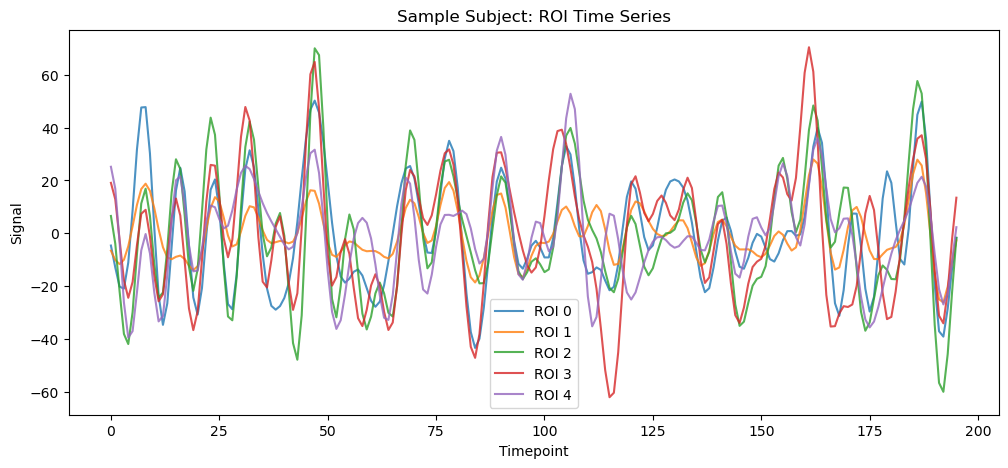

In [50]:
import matplotlib.pyplot as plt

sample = abide["rois_ho"][0]

# Handle both cases (array vs file path)
if not isinstance(sample, np.ndarray):
    sample = np.loadtxt(sample)

print("Shape:", sample.shape)
plt.figure(figsize=(12, 5))
for roi_idx in range(5):
    plt.plot(sample[:, roi_idx], label=f"ROI {roi_idx}", alpha=0.8)

plt.title("Sample Subject: ROI Time Series")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.legend()
plt.show()

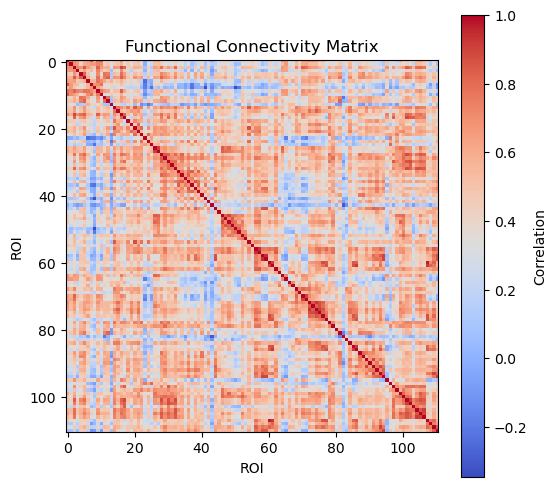

In [51]:
corr = np.corrcoef(sample, rowvar=False)
corr = np.nan_to_num(corr)

plt.figure(figsize=(6, 6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.title("Functional Connectivity Matrix")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.show()

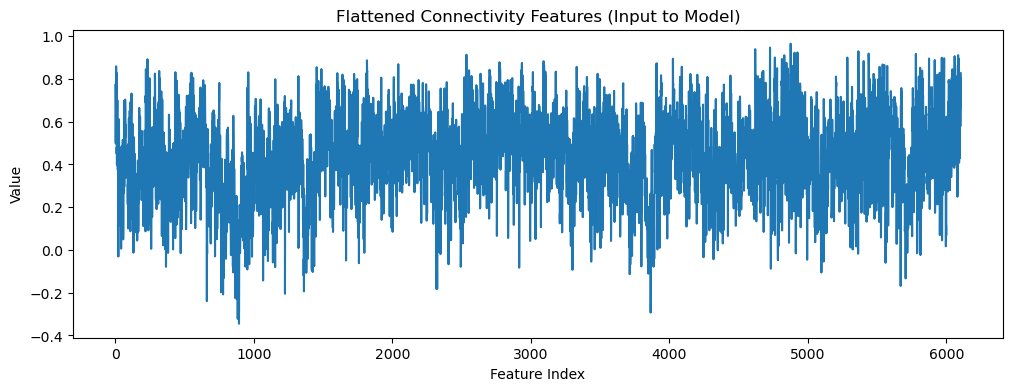

In [52]:
subject_features = X[0]

plt.figure(figsize=(12, 4))
plt.plot(subject_features)
plt.title("Flattened Connectivity Features (Input to Model)")
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.show()

In [53]:
type(abide["rois_ho"][0])

numpy.ndarray

In [54]:
X = np.vstack(X_list)
pheno_valid = pheno.iloc[valid_idx].reset_index(drop=True)

y = pheno_valid["DX_GROUP"].map({1: 1, 2: 0}).values

print("X:", X.shape)
print("y:", y.shape)

X: (300, 6105)
y: (300,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (240, 6105)
X_test: (60, 6105)
y_train: (240,)
y_test: (60,)


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

In [57]:
baseline_clf

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

In [58]:
baseline_clf.fit(X_train, y_train)
print("Baseline model trained ✅")

Baseline model trained ✅


In [59]:
y_pred = baseline_clf.predict(X_test)
y_proba = baseline_clf.predict_proba(X_test)[:, 1]

In [60]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7167
F1 Score: 0.6222
ROC-AUC: 0.7783

Classification Report:

              precision    recall  f1-score   support

           0     0.7250    0.8286    0.7733        35
           1     0.7000    0.5600    0.6222        25

    accuracy                         0.7167        60
   macro avg     0.7125    0.6943    0.6978        60
weighted avg     0.7146    0.7167    0.7104        60

Confusion Matrix:

[[29  6]
 [11 14]]


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

svm_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", probability=True, random_state=42))
])

svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
y_proba = svm_clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7
F1 Score: 0.6087
ROC-AUC: 0.7686

Classification Report:

              precision    recall  f1-score   support

           0     0.7179    0.8000    0.7568        35
           1     0.6667    0.5600    0.6087        25

    accuracy                         0.7000        60
   macro avg     0.6923    0.6800    0.6827        60
weighted avg     0.6966    0.7000    0.6951        60

Confusion Matrix:

[[28  7]
 [11 14]]


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

rbf_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

rbf_svm.fit(X_train, y_train)

y_pred = rbf_svm.predict(X_test)
y_proba = rbf_svm.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6333
F1 Score: 0.2143
ROC-AUC: 0.7137

Classification Report:

              precision    recall  f1-score   support

           0     0.6140    1.0000    0.7609        35
           1     1.0000    0.1200    0.2143        25

    accuracy                         0.6333        60
   macro avg     0.8070    0.5600    0.4876        60
weighted avg     0.7749    0.6333    0.5331        60

Confusion Matrix:

[[35  0]
 [22  3]]


### PCA

In [63]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

pca_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)),
    ("clf", SVC(kernel="linear", probability=True, random_state=42))
])

pca_svm.fit(X_train, y_train)

y_pred = pca_svm.predict(X_test)
y_proba = pca_svm.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

Accuracy: 0.6167
F1 Score: 0.4889
ROC-AUC: 0.6629


## Lets add more data :)

In [33]:
abide = fetch_abide_pcp(
    data_dir="data",
    n_subjects=300,   # try 300 first
    pipeline="cpac",
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=["rois_ho"],
    quality_checked=True,
    verbose=1,
)

[fetch_abide_pcp] Dataset found in data/ABIDE_pcp

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/SDSU_0050203_ro
is_ho.1D ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/SDSU_0050204_ro
is_ho.1D ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/USM_0050448_roi
s_ho.1D ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/filt_noglobal/rois_ho/USM_0050449_roi
s_ho.1D ...

[fetch_abide_pcp]  ...done. (0 seconds, 0 min)

In [64]:
from sklearn.linear_model import LogisticRegression

weighted_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # KEY CHANGE
        random_state=42
    ))
])

weighted_clf.fit(X_train, y_train)

y_pred = weighted_clf.predict(X_test)
y_proba = weighted_clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7166666666666667
F1: 0.6222222222222222
ROC-AUC: 0.785142857142857

Confusion Matrix:
 [[29  6]
 [11 14]]


In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

6105 connectivity features -> MLP encoder -> 128-d embedding -> classifier

In [66]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)
print(X_test_t.shape, y_test_t.shape)

torch.Size([240, 6105]) torch.Size([240])
torch.Size([60, 6105]) torch.Size([60])


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [68]:
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [69]:
class NeuroAlignMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, embed_dim=128, num_classes=2):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU()
        )
        
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z)
        return logits, z

In [76]:
input_dim = X_train.shape[1]

model = NeuroAlignMLP(input_dim=input_dim, hidden_dim=128, embed_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

print(model)

NeuroAlignMLP(
  (encoder): Sequential(
    (0): Linear(in_features=6105, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
  )
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


In [77]:
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, z = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/100 - Loss: 0.6815
Epoch 5/100 - Loss: 0.1171
Epoch 10/100 - Loss: 0.0527
Epoch 15/100 - Loss: 0.0102
Epoch 20/100 - Loss: 0.0109
Epoch 25/100 - Loss: 0.0364
Epoch 30/100 - Loss: 0.0594
Epoch 35/100 - Loss: 0.1682
Epoch 40/100 - Loss: 0.0868
Epoch 45/100 - Loss: 0.0057
Epoch 50/100 - Loss: 0.0031
Epoch 55/100 - Loss: 0.0008
Epoch 60/100 - Loss: 0.0010
Epoch 65/100 - Loss: 0.0010
Epoch 70/100 - Loss: 0.0004
Epoch 75/100 - Loss: 0.0006
Epoch 80/100 - Loss: 0.0021
Epoch 85/100 - Loss: 0.0050
Epoch 90/100 - Loss: 0.0009
Epoch 95/100 - Loss: 0.0012
Epoch 100/100 - Loss: 0.0004


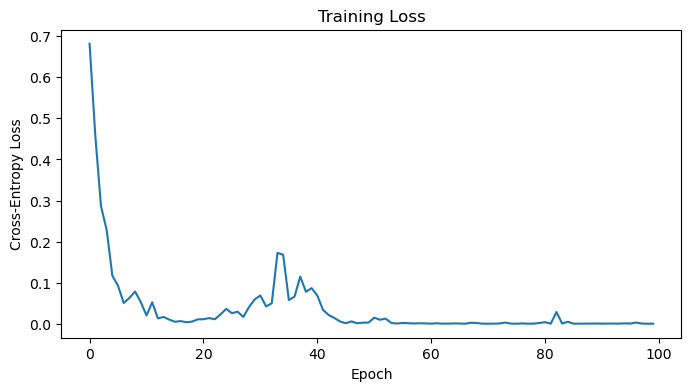

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()

In [79]:
model.eval()

all_logits = []
all_probs = []
all_preds = []
all_true = []
all_embeds = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, z = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_true.append(yb.cpu())
        all_embeds.append(z.cpu())

In [80]:
y_true_nn = torch.cat(all_true).numpy()
y_pred_nn = torch.cat(all_preds).numpy()
y_proba_nn = torch.cat(all_probs).numpy()
embeds_nn = torch.cat(all_embeds).numpy()

acc = accuracy_score(y_true_nn, y_pred_nn)
f1 = f1_score(y_true_nn, y_pred_nn)
auc = roc_auc_score(y_true_nn, y_proba_nn)

print("MLP Accuracy:", round(acc, 4))
print("MLP F1 Score:", round(f1, 4))
print("MLP ROC-AUC:", round(auc, 4))

print("\nClassification Report:\n")
print(classification_report(y_true_nn, y_pred_nn, digits=4))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true_nn, y_pred_nn))

MLP Accuracy: 0.65
MLP F1 Score: 0.5116
MLP ROC-AUC: 0.72

Classification Report:

              precision    recall  f1-score   support

           0     0.6667    0.8000    0.7273        35
           1     0.6111    0.4400    0.5116        25

    accuracy                         0.6500        60
   macro avg     0.6389    0.6200    0.6195        60
weighted avg     0.6435    0.6500    0.6374        60

Confusion Matrix:

[[28  7]
 [14 11]]


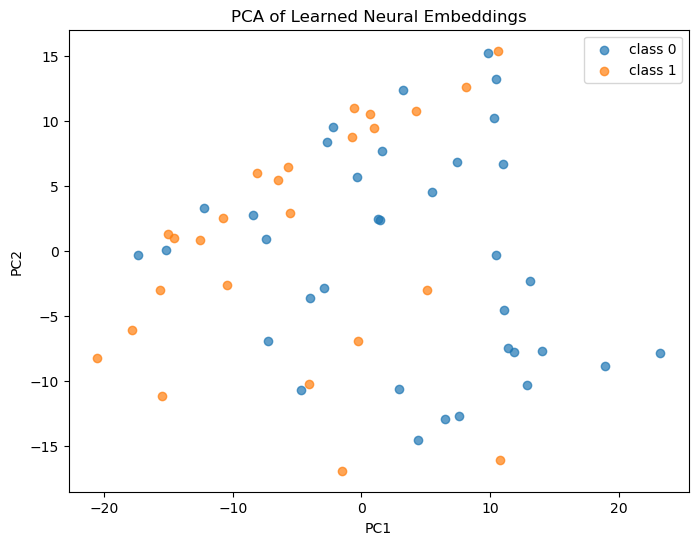

In [81]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(embeds_nn)

plt.figure(figsize=(8, 6))
for label in np.unique(y_true_nn):
    idx = y_true_nn == label
    plt.scatter(
        embeds_2d[idx, 0],
        embeds_2d[idx, 1],
        label=f"class {label}",
        alpha=0.7
    )

plt.title("PCA of Learned Neural Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()